# A Simple Method to Project Sentinel-2 Reflectance Data onto a HEALPix Grid

In [1]:
import healpy as hp
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
# Open a remote Zarr dataset hosted at the given URL using xarray
# Zarr format efficiently stores multidimensional arrays, especially useful for large geospatial datasets
ds = xr.open_zarr('https://data-taos.ifremer.fr/GRID4EARTH/S2A_OPER_MSI_L1B_GR_2APS_20250724T145646_S20250724T112804_D06_N05.11_B02.zarr')

# Display dataset structure and metadata
# This prints a summary including dimensions, coordinates, data variables, and attributes
ds

<xarray.Dataset> Size: 118MB
Dimensions:      (y: 2304, x: 2552)
Coordinates:
    band         int64 8B ...
    spatial_ref  int64 8B ...
  * x            (x) float64 20kB 0.5 1.5 2.5 ... 2.55e+03 2.55e+03 2.552e+03
  * y            (y) float64 18kB 0.5 1.5 2.5 ... 2.302e+03 2.302e+03 2.304e+03
Data variables:
    B02          (y, x) float32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    latitude     (y, x) float64 47MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    longitude    (y, x) float64 47MB dask.array<chunksize=(512, 512), meta=np.ndarray>

In [3]:
# Define HEALPix resolution level (higher value means higher spatial resolution)
level = 19

# Compute the HEALPix pixel indices ("hidx") corresponding to each point defined by longitude and latitude
# "2**level" sets the resolution of the HEALPix grid (higher Nside means smaller pixels)
# ds.longitude.values.flatten() and ds.latitude.values.flatten() are arrays of longitude and latitude in degrees
# "lonlat=True" indicates the input coordinates are in longitude-latitude format (degrees), not theta-phi (radians)
# "nest=True" means the HEALPix indexing uses "nested" ordering rather than "ring" ordering
hidx = hp.ang2pix(2**level,
                  ds.longitude.values.flatten(),
                  ds.latitude.values.flatten(),
                  lonlat=True,
                  nest=True)

# Find the unique HEALPix pixel indices ("h") and also return indices ("ih") 
# which map each original coordinate to its unique pixel index
h, ih = np.unique(hidx, return_inverse=True)

# Convert the unique HEALPix pixel indices ("h") back into their corresponding pixel center coordinates (lon, lat)
# This provides the central longitude and latitude of each unique HEALPix pixel
lon, lat = hp.pix2ang(2**level,
                      h,
                      lonlat=True,
                      nest=True)

In [4]:
# Count how many original points fall into each unique HEALPix pixel
# "ih" maps each point to its pixel; bincount gives the number of occurrences per pixel
image_hit = np.bincount(ih)

# Sum the values of band "B02" from the original dataset for each HEALPix pixel
# "weights" sums the B02 values that fall into each pixel defined by "ih"
image_b02 = np.bincount(ih, weights=ds.B02.values.flatten())

# Compute the mean B02 reflectance value for each HEALPix pixel
# by dividing the sum of B02 values by the number of points (hits) in each pixel
image_b02 /= image_hit

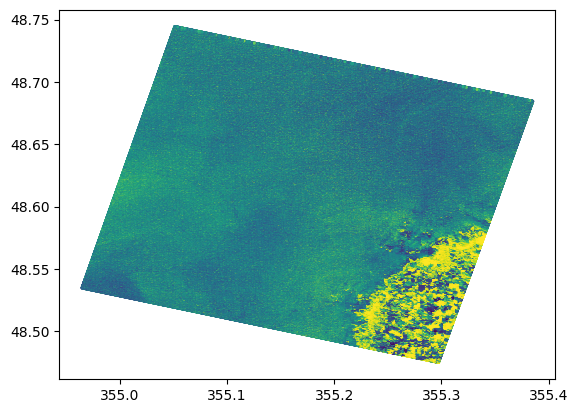

In [5]:
# Scatter plot displaying the HEALPix pixel centers (lon, lat) 
# Colored by an ampirical normalized version of the B02 reflectance
# Normalization is done with hyperbolic tangent (tanh) of the standardized values (mean-subtracted, std-scaled)

plt.scatter(lon, lat,
            c=np.tanh((image_b02 - np.median(image_b02)) / np.std(image_b02)),
            s=1)